# Assignment 4 - Decision Tree Model and Business Interpretation

- **Course:** MBAI 5310G: AI Programming - Ontario Tech University
- **Business:** FreshBasket Subscription Grocery Delivery
- **Dataset:** FreshBasket Customer Churn Dataset
- **Target:** `Churned` (Yes / No) - binary classification
- **Model:** Decision Tree Classifier

This notebook builds a Decision Tree classification model on a subscription-grocery customer dataset and interprets the results from a business perspective.

## Task 1: Understand the Business Problem

**What is the business about?**
FreshBasket is a subscription-based grocery delivery service operating in the Greater Toronto Area. Customers choose weekly or monthly plans across different subscription tiers, delivery windows, and payment methods. Revenue comes from recurring subscription fees and ongoing grocery orders, so the business depends heavily on repeat customers.

**What problem is the business trying to solve?**
Customer churn. When customers cancel or stop renewing, FreshBasket loses recurring revenue and has to spend more on acquiring new customers to replace them. The agency wants to identify customers who are at risk of leaving **before** they actually cancel, so it can intervene early.

**What decision can machine learning help the business make?**
ML can help FreshBasket decide *which customers should receive retention attention* - a service-recovery follow-up, a personalised discount, a check-in from customer support, or a recommendation to switch to a better-fitting subscription plan. The Decision Tree also tells the business *why* customers are at risk via feature importance, which can guide operational changes (e.g., delivery improvements in specific regions).

**What is the target variable in the dataset?**
`Churned` - whether the customer cancelled or did not renew (`Yes` / `No`). Encoded as `1` / `0` for modelling.

**What are the input features?**
- Customer demographics: `Age_Group`, `Region`
- Subscription information: `Subscription_Type`, `Payment_Method`, `Delivery_Window`, `Membership_Length_Months`, `Discount_Used`
- Spending behaviour: `Monthly_Spend`, `Average_Order_Value`, `Orders_Last_3_Months`
- Service quality and engagement: `Delivery_Issues_Last_3_Months`, `Customer_Service_Tickets`, `App_Engagement_Score`, `Satisfaction_Score`

`Customer_ID` is excluded - it is only an identifier with no predictive value.

**Why is this prediction useful for the business?**
Retaining an existing customer is much cheaper than acquiring a new one, so even a moderately accurate churn signal can have a meaningful financial impact. A reliable prediction lets FreshBasket prioritise limited support and marketing resources on the customers most likely to leave, investigate operational pain points (e.g., delivery issues in a specific region) that drive churn, and design plans that better fit different customer segments.

## Task 2: Prepare the Data

### Step 2.1: Load the Dataset

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")  # suppress openpyxl style warnings on this XLSX

df = pd.read_excel("freshbasket_customer_churn_dataset.xlsx")
df.head()

,Customer_ID,Age_Group,Region,Subscription_Type,Payment_Method,Delivery_Window,Membership_Length_Months,Monthly_Spend,Average_Order_Value,Orders_Last_3_Months,Delivery_Issues_Last_3_Months,Customer_Service_Tickets,Discount_Used,App_Engagement_Score,Satisfaction_Score,Churned
0,FB-1001,18-24,Toronto,Family,Credit Card,Evening,18,267.23,140.14,9,0,0,No,70.0,3.0,No
1,FB-1002,45-54,Toronto,Premium,Credit Card,Morning,7,349.36,179.20,10,1,1,No,14.0,3.0,Yes
2,FB-1003,35-44,Mississauga,Basic,Credit Card,Morning,4,132.08,25.00,6,0,0,Yes,46.0,3.0,No
3,FB-1004,35-44,Ajax,Basic,Credit Card,Afternoon,8,80.71,25.00,0,1,0,Yes,42.0,5.0,Yes
4,FB-1005,45-54,Markham,Family,Credit Card,Morning,21,218.95,31.10,1,0,0,No,88.0,3.0,No


### Step 2.2: Inspect the Dataset

Check shape, data types, missing values, duplicates, and target distribution.

In [2]:
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (425, 16)


In [3]:
print("Column names:")
print(df.columns.tolist())

Column names:
['Customer_ID', 'Age_Group', 'Region', 'Subscription_Type', 'Payment_Method', 'Delivery_Window', 'Membership_Length_Months', 'Monthly_Spend', 'Average_Order_Value', 'Orders_Last_3_Months', 'Delivery_Issues_Last_3_Months', 'Customer_Service_Tickets', 'Discount_Used', 'App_Engagement_Score', 'Satisfaction_Score', 'Churned']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer_ID                    425 non-null    str    
 1   Age_Group                      425 non-null    str    
 2   Region                         416 non-null    str    
 3   Subscription_Type              425 non-null    str    
 4   Payment_Method                 425 non-null    str    
 5   Delivery_Window                425 non-null    str    
 6   Membership_Length_Months       425 non-null    int64  
 7   Monthly_Spend                  419 non-null    float64
 8   Average_Order_Value            425 non-null    float64
 9   Orders_Last_3_Months           425 non-null    int64  
 10  Delivery_Issues_Last_3_Months  425 non-null    int64  
 11  Customer_Service_Tickets       425 non-null    int64  
 12  Discount_Used                  425 non-null    str    
 13  A

In [5]:
print("Data types:")
print(df.dtypes)

Data types:
Customer_ID                          str
Age_Group                            str
Region                               str
Subscription_Type                    str
Payment_Method                       str
Delivery_Window                      str
Membership_Length_Months           int64
Monthly_Spend                    float64
Average_Order_Value              float64
Orders_Last_3_Months               int64
Delivery_Issues_Last_3_Months      int64
Customer_Service_Tickets           int64
Discount_Used                        str
App_Engagement_Score             float64
Satisfaction_Score               float64
Churned                              str
dtype: object


In [6]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Customer_ID                      0
Age_Group                        0
Region                           9
Subscription_Type                0
Payment_Method                   0
Delivery_Window                  0
Membership_Length_Months         0
Monthly_Spend                    6
Average_Order_Value              0
Orders_Last_3_Months             0
Delivery_Issues_Last_3_Months    0
Customer_Service_Tickets         0
Discount_Used                    0
App_Engagement_Score             4
Satisfaction_Score               6
Churned                          0
dtype: int64


In [7]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 5


In [8]:
print("Target distribution:")
print(df["Churned"].value_counts())
print()
print("Target distribution (proportions):")
print(df["Churned"].value_counts(normalize=True).round(3))

Target distribution:
Churned
No     307
Yes    118
Name: count, dtype: int64

Target distribution (proportions):
Churned
No     0.722
Yes    0.278
Name: proportion, dtype: float64


The target is **imbalanced**: roughly 72% `No` versus 28% `Yes`. This is important to remember when interpreting accuracy later - a trivial "predict everyone stays" model would score around 0.72 on accuracy alone.

### Step 2.3: Clean the Dataset

Drop duplicate rows, then fill missing values (median for numerical, mode for categorical).

In [9]:
df_clean = df.copy()

# Drop duplicate rows
df_clean = df_clean.drop_duplicates()
print("Shape after removing duplicates:", df_clean.shape)
print("Duplicate rows after cleaning:", df_clean.duplicated().sum())

Shape after removing duplicates: (420, 16)
Duplicate rows after cleaning: 0


In [10]:
numeric_columns = [
    "Membership_Length_Months", "Monthly_Spend", "Average_Order_Value",
    "Orders_Last_3_Months", "Delivery_Issues_Last_3_Months",
    "Customer_Service_Tickets", "App_Engagement_Score", "Satisfaction_Score"
]

categorical_columns = [
    "Age_Group", "Region", "Subscription_Type",
    "Payment_Method", "Delivery_Window", "Discount_Used"
]

In [11]:
# Fill missing values in numerical columns with the median
for col in numeric_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill missing values in categorical columns with the mode
for col in categorical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Missing values after cleaning:")
print(df_clean.isnull().sum().sum(), "missing values remaining")

Missing values after cleaning:
0 missing values remaining


### Step 2.4: Separate Features and Target

`Customer_ID` is excluded - it's an identifier, not a predictive feature. The target `Churned` is mapped from `Yes`/`No` to `1`/`0`.

In [12]:
feature_columns = numeric_columns + categorical_columns

X = df_clean[feature_columns]
y = df_clean["Churned"].map({"No": 0, "Yes": 1})

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print()
print("Target distribution after encoding:")
print(y.value_counts())

Shape of X: (420, 14)
Shape of y: (420,)

Target distribution after encoding:
Churned
0    304
1    116
Name: count, dtype: int64


### Step 2.5: Train/Test Split

80% training, 20% testing, stratified by the target to preserve class proportions in both sets (important given the imbalance).

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (336, 14)
X_test shape: (84, 14)
y_train shape: (336,)
y_test shape: (84,)


### Step 2.6: Preprocessing (Categorical + Numerical)

Scale numerical features with `StandardScaler` and one-hot encode categorical features. The transformer is fit on the training data only to avoid data leakage.

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Build a list of processed feature names (used later for feature-importance plotting)
processed_feature_names = numeric_columns + list(
    preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_columns)
)

print("X_train shape after preprocessing:", X_train_processed.shape)
print("X_test shape after preprocessing: ", X_test_processed.shape)
print("Number of processed features:", len(processed_feature_names))

X_train shape after preprocessing: (336, 32)
X_test shape after preprocessing:  (84, 32)
Number of processed features: 32


## Task 3: Train a Decision Tree Classification Model

Train a Decision Tree with `max_depth=4` to keep it interpretable and reduce the risk of overfitting. Then train an unrestricted tree (`max_depth=None`) for direct comparison so overfitting is visible.

### Step 3.1: Train the Decision Tree (max_depth = 4)

In [15]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

decision_tree_model.fit(X_train_processed, y_train)
print("Decision Tree model trained successfully.")
print(decision_tree_model)

Decision Tree model trained successfully.
DecisionTreeClassifier(max_depth=4, random_state=42)


### Step 3.2: Make Predictions

In [16]:
y_train_pred = decision_tree_model.predict(X_train_processed)
y_test_pred = decision_tree_model.predict(X_test_processed)

print("First 10 test predictions:", y_test_pred[:10])

First 10 test predictions: [0 0 0 0 0 1 0 0 0 0]


### Step 3.3: Confusion Matrix

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[59  2]
 [18  5]]


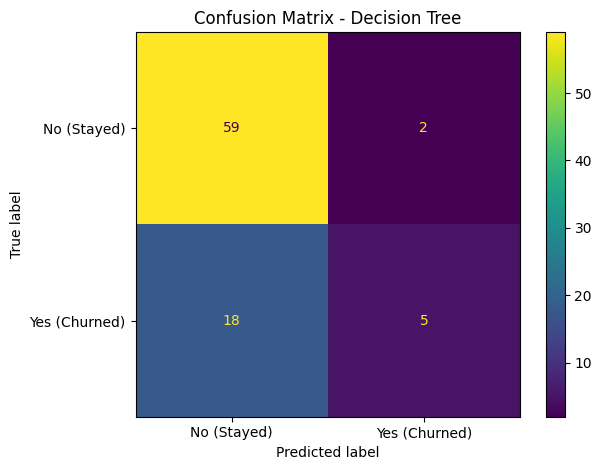

In [18]:
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No (Stayed)", "Yes (Churned)"]
).plot()
plt.title("Confusion Matrix - Decision Tree")
plt.tight_layout()
plt.show()

### Step 3.4: Accuracy, Precision, Recall, F1-score

In [19]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, zero_division=0)
recall = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)

print("Decision Tree (max_depth=4) - Test Set Metrics")
print("-" * 50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Decision Tree (max_depth=4) - Test Set Metrics
--------------------------------------------------
Accuracy:  0.7619
Precision: 0.7143
Recall:    0.2174
F1-score:  0.3333


In [20]:
print("Classification Report:")
print(classification_report(y_test, y_test_pred,
                            target_names=["No (Stayed)", "Yes (Churned)"],
                            zero_division=0))

Classification Report:
               precision    recall  f1-score   support

  No (Stayed)       0.77      0.97      0.86        61
Yes (Churned)       0.71      0.22      0.33        23

     accuracy                           0.76        84
    macro avg       0.74      0.59      0.59        84
 weighted avg       0.75      0.76      0.71        84



### Step 3.5: Training Accuracy vs Testing Accuracy (Overfitting Check)

A large gap between training and testing accuracy is a strong signal of overfitting. Compare the controlled tree (`max_depth=4`) against an unrestricted tree (`max_depth=None`) to make the contrast explicit.

In [21]:
# Controlled tree accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Controlled Decision Tree (max_depth = 4)")
print(f"  Training Accuracy: {train_accuracy:.4f}")
print(f"  Testing Accuracy:  {test_accuracy:.4f}")
print(f"  Gap (train - test): {train_accuracy - test_accuracy:.4f}")

Controlled Decision Tree (max_depth = 4)
  Training Accuracy: 0.8155
  Testing Accuracy:  0.7619
  Gap (train - test): 0.0536


In [22]:
# Compare with an unrestricted (likely overfit) tree
overfit_tree_model = DecisionTreeClassifier(max_depth=None, random_state=42)
overfit_tree_model.fit(X_train_processed, y_train)

y_train_pred_overfit = overfit_tree_model.predict(X_train_processed)
y_test_pred_overfit = overfit_tree_model.predict(X_test_processed)

overfit_train_acc = accuracy_score(y_train, y_train_pred_overfit)
overfit_test_acc = accuracy_score(y_test, y_test_pred_overfit)

print("Overfitted Decision Tree (max_depth = None)")
print(f"  Training Accuracy: {overfit_train_acc:.4f}")
print(f"  Testing Accuracy:  {overfit_test_acc:.4f}")
print(f"  Gap (train - test): {overfit_train_acc - overfit_test_acc:.4f}")

Overfitted Decision Tree (max_depth = None)
  Training Accuracy: 1.0000
  Testing Accuracy:  0.7024
  Gap (train - test): 0.2976


**Brief explanation - is the model overfitting?**

The unrestricted tree achieves perfect (100%) accuracy on the training data but drops sharply on the test data - the textbook overfitting signature. The controlled tree (`max_depth=4`) has a much smaller train-test gap (a few percentage points), meaning it's generalising rather than memorising. A more detailed business-context discussion is in **Task 4**.

### Step 3.6: Visualise the Decision Tree

The plot shows the actual decision rules the model learned. This is useful for explaining results to non-technical stakeholders at FreshBasket.

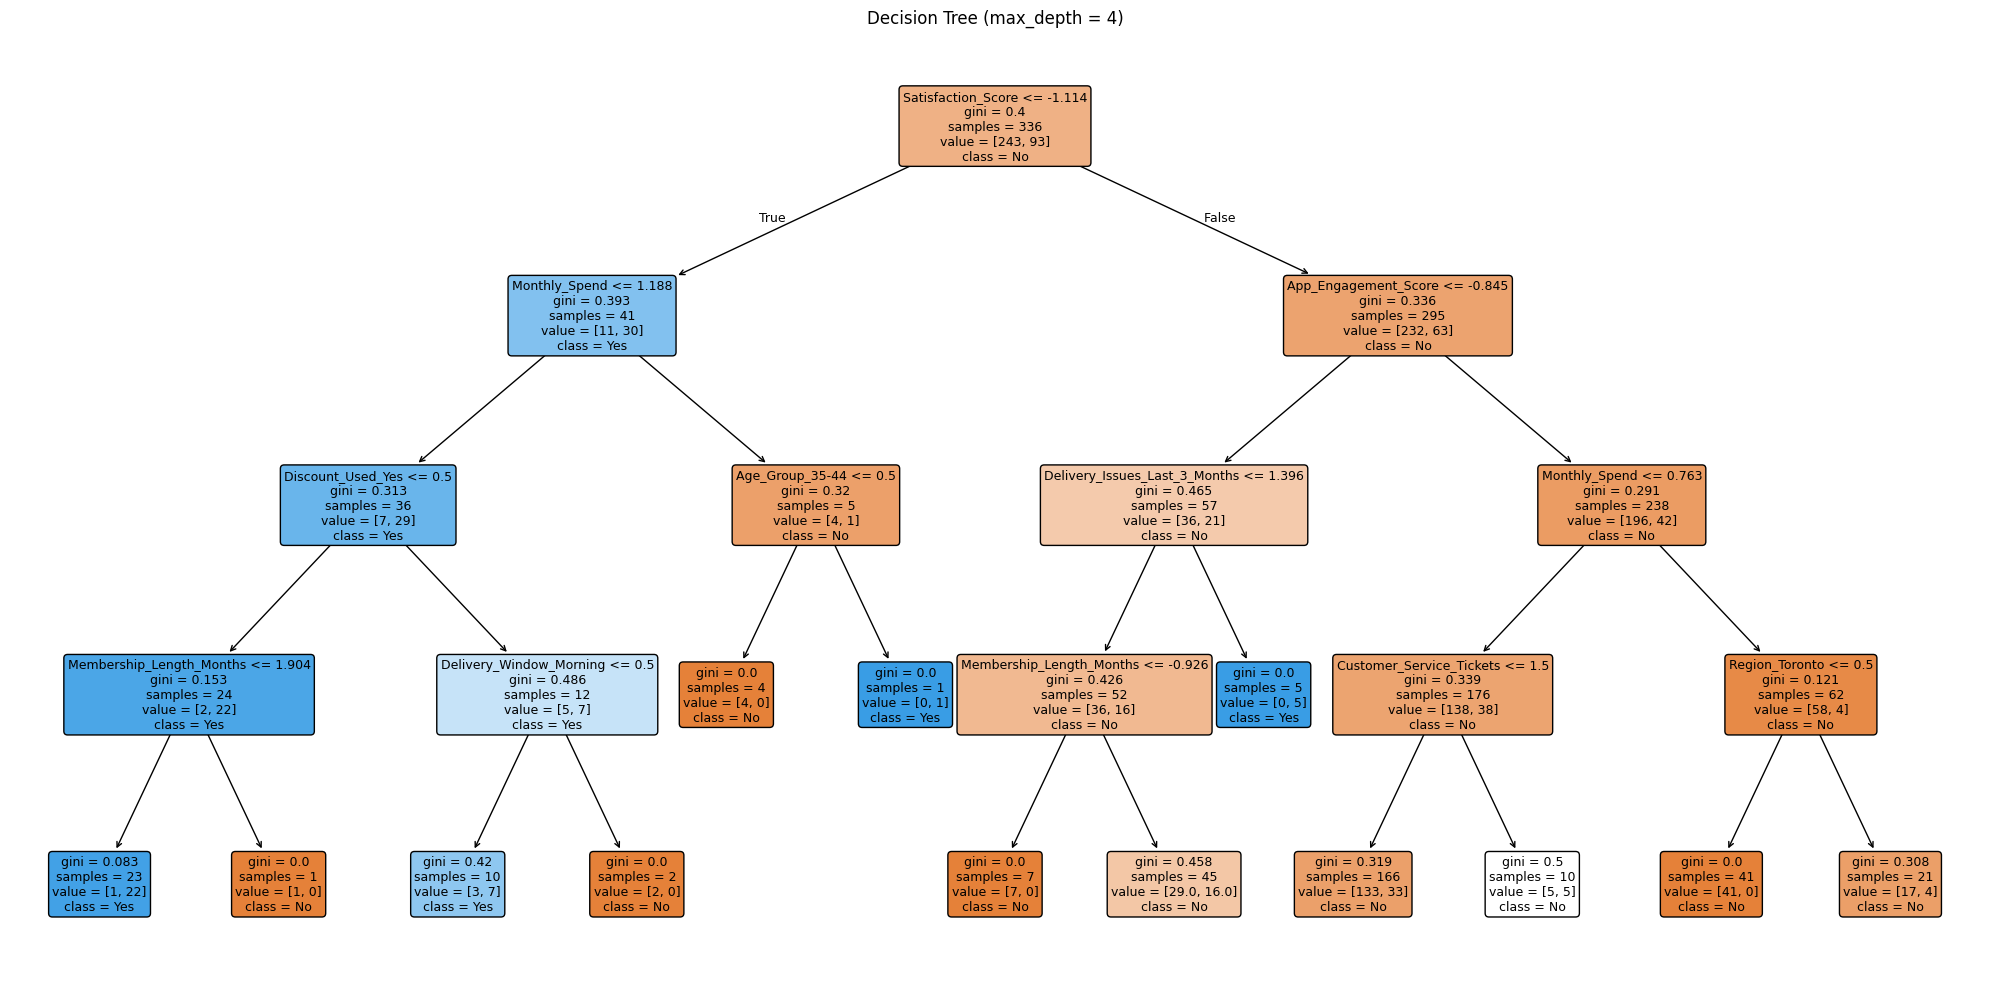

In [23]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    decision_tree_model,
    feature_names=processed_feature_names,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree (max_depth = 4)")
plt.tight_layout()
plt.show()

## Task 4: Business Interpretation of Model Results

First, compute and visualise feature importance, then answer the business interpretation questions.

### Step 4.1: Feature Importance

In [24]:
dt_feature_importance = pd.DataFrame({
    "Feature": processed_feature_names,
    "Importance": decision_tree_model.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("Top 10 Most Important Features:")
display(dt_feature_importance.head(10))

Top 10 Most Important Features:


,Feature,Importance
0,Satisfaction_Score,0.445088
1,Monthly_Spend,0.122539
2,Delivery_Issues_Last_3_Months,0.100686
3,App_Engagement_Score,0.078033
4,Membership_Length_Months,0.075650
5,Discount_Used_Yes,0.040937
6,Customer_Service_Tickets,0.039409
7,Delivery_Window_Morning,0.037611
8,Age_Group_35-44,0.036844
9,Region_Toronto,0.023204


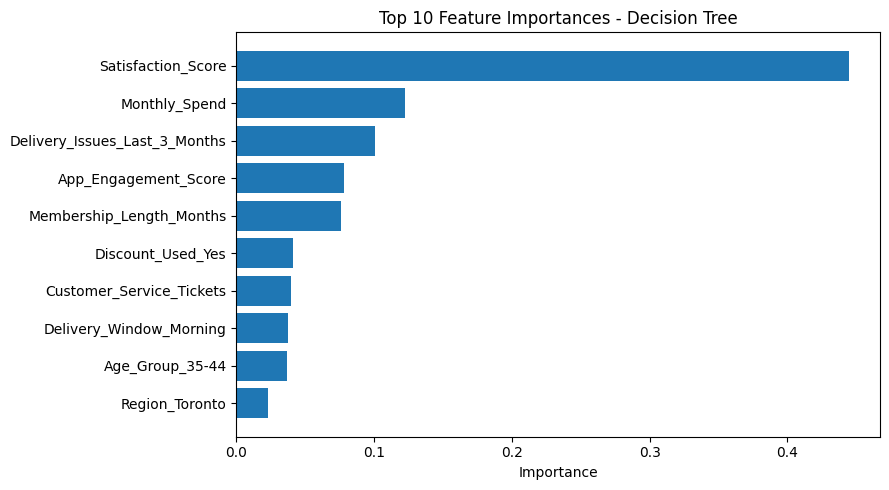

In [25]:
# Bar plot of the top 10 features
top10 = dt_feature_importance.head(10)
plt.figure(figsize=(9, 5))
plt.barh(top10["Feature"][::-1], top10["Importance"][::-1])
plt.title("Top 10 Feature Importances - Decision Tree")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Final Business Interpretation

**How well did the Decision Tree model perform?**
On the held-out test set the controlled Decision Tree (`max_depth=4`) reached **Accuracy ≈ 0.76, Precision ≈ 0.71, Recall ≈ 0.22, F1 ≈ 0.33**. The accuracy number looks reasonable in isolation, but it is misleading on its own because the target is imbalanced (≈72% `No` / ≈28% `Yes`) - a naive "predict everyone stays" model would already score about 0.72. The honest story is that the model is **good at not over-alerting** (when it does predict churn it is right about 71% of the time) but **bad at catching churners** (it identifies only about 22% of customers who actually leave). For a retention business this is the wrong trade-off, so the model is best treated as a starting point that needs further work before operational use.

**Is there a large difference between training accuracy and testing accuracy?**
For the controlled tree, training accuracy is ≈0.82 and testing accuracy is ≈0.76 - a gap of around 5–6 percentage points. That is a **small** gap and indicates reasonable generalisation. For the unrestricted tree the gap balloons to roughly 30 percentage points (training 1.00, testing ≈0.70) - the classic overfitting signature.

**Does the model show signs of overfitting? Why or why not?**
The controlled tree (`max_depth=4`) shows **only mild overfitting**: train and test accuracies are close, which suggests the depth cap is working as intended. The unrestricted tree clearly overfits - it has memorised the training set and lost predictive power on new data. Capping `max_depth` is the simplest and most effective control here.

**Which evaluation metric is most important for this business problem?**
**Recall** is arguably the most important metric for FreshBasket, with **F1-score** as a close second. The cost of a missed churner (lost recurring revenue from a cancelled subscription) is typically higher than the cost of an unnecessary retention offer (a one-off discount or a support call). The current model's recall of ≈0.22 is therefore the biggest concern - the business would be missing roughly four out of every five customers who actually churn. Accuracy is a poor primary metric here because of the class imbalance.

**What do false positives mean in this business context?**
The model predicts the customer will churn, but they actually stay. FreshBasket would spend retention resources (discount code, support follow-up, account-manager outreach) on a customer who was never going to leave - **wasted retention budget** and possibly some mild annoyance for the customer.

**What do false negatives mean in this business context?**
The model predicts the customer will stay, but they actually churn. FreshBasket misses an opportunity to intervene before the customer cancels - **lost recurring revenue** and a customer-acquisition cost to replace them. In a subscription business, this is usually the more expensive error.

**Which features were most important in the Decision Tree model?**
The top features (see plot above) are **Satisfaction_Score** (clearly dominant), **Monthly_Spend**, **Delivery_Issues_Last_3_Months**, **App_Engagement_Score**, and **Membership_Length_Months**. Service quality and engagement signals dominate; demographic variables like `Age_Group` and `Region` contribute much less. This is consistent with intuition for a subscription business: how the customer experiences the service matters more than who they are.

**How can these important features help the business make better decisions?**
- **Satisfaction_Score** dominates: treat it as the most valuable single signal. Trigger retention outreach whenever a customer's satisfaction drops below a threshold.
- **Delivery_Issues_Last_3_Months** matters: invest in delivery reliability and proactively reach out to customers who have had recent delivery problems, even if they haven't complained.
- **App_Engagement_Score** is in the top features: design re-engagement nudges (push notifications, personalised recipe ideas, reminder emails) for customers whose app activity has dropped.
- **Monthly_Spend** and **Membership_Length_Months**: high-value or long-tenured customers should get the highest-touch retention treatment because their lifetime value is largest.
- Operational, not just marketing, action: feature importance points the business toward fixing root causes (delivery reliability, app experience) rather than only patching with discounts.

**What is one possible limitation or bias in the model or dataset?**
The dataset is **synthetic and small** (≈420 rows after cleaning, only ≈118 churners) and the target is **imbalanced**. With so few churn examples, the tree has very limited material to learn from on the minority class, which is the most likely reason recall is so low. There is also a **fairness consideration**: the model uses `Age_Group` and `Region` directly, so any over- or under-representation of customer groups in the training data could lead to unfair treatment - e.g., over- or under-prioritising retention contact for customers in a particular region.

**Why should human judgment still be used when making business decisions based on model results?**
- Predictions are estimates, not guarantees - especially with this model's low recall, important judgment calls (e.g., handling a high-value VIP) should not depend on the model alone.
- The dataset misses real-world context that a retention manager would know: a known service outage that month, a competitor promotion in a specific region, a customer who has flagged a personal life event.
- Retention actions touch customer experience: heavy-handed targeting can feel intrusive and may *cause* churn rather than prevent it. A human should sense-check tone, frequency, and offer size.
- The model should be a **decision-support tool** that helps the team prioritise outreach and points to operational issues to fix - not an automated cancel-prevention engine.

---

## Summary

| Metric (test set) | Score |
|---|---:|
| Accuracy | 0.762 |
| Precision | 0.714 |
| Recall | 0.217 |
| F1-score | 0.333 |

| Tree variant | Training accuracy | Testing accuracy | Gap |
|---|---:|---:|---:|
| Controlled (`max_depth=4`) | 0.816 | 0.762 | 0.054 |
| Unrestricted (`max_depth=None`) | 1.000 | 0.702 | 0.298 |

**Selected model:** Decision Tree with `max_depth=4` - generalises far better than the unrestricted tree and remains interpretable.

**Top features driving the prediction:** `Satisfaction_Score`, `Monthly_Spend`, `Delivery_Issues_Last_3_Months`, `App_Engagement_Score`, `Membership_Length_Months`.

**Main caveat:** the model's recall is low (≈0.22) on the minority `Churned = Yes` class. For a retention business that is the wrong trade-off, so the model should be used as decision support and a starting point for further iteration, not as an operational cancel-prevention system.